In [4]:
import requests
import os

# folder path to save the files
folder_path = 'airnow'

# files to download
files = [
    {'year': 2021, 'sfx': '2021_YTD'},
    {'year': 2022, 'sfx': '2022_YTD'},
    {'year': 2023, 'sfx': '2023_YTD'},
    {'year': 2023, 'sfx': '2023_12_MTD'}
]

# create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

# download and save the files
for file in files:

    # construct the URL
    url = f'https://dosairnowdata.org/dos/historical/BanjaLuka/{file['year']}/BanjaLuka_PM2.5_{file['sfx']}.csv'

    # extract the filename from the URL
    filename = url.split('/')[-1]

    # file path to save the downloaded file
    file_path = os.path.join(folder_path, filename)

    # download the file and save it
    response = requests.get(url)

    if response.status_code == 200:

        with open(file_path, 'wb') as file:
            file.write(response.content)

        print(f'File {filename} downloaded and saved successfully.')

    else:
        print(f'Failed to download the file {filename}.')
    #}
#}


File BanjaLuka_PM2.5_2021_YTD.csv downloaded and saved successfully.
File BanjaLuka_PM2.5_2022_YTD.csv downloaded and saved successfully.
File BanjaLuka_PM2.5_2023_YTD.csv downloaded and saved successfully.
File BanjaLuka_PM2.5_2023_12_MTD.csv downloaded and saved successfully.


In [3]:
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
import time
import requests
import io
import pandas as pd

# sensor index
#sensor_index = '33099' # Cara Lazara
#sensor_index = '37541' # Nikole Pasica
sensor_index = '91941' # Magazin Buka

# define the API URL
url = f'https://api.purpleair.com/v1/sensors/{sensor_index}/history/csv'

# define the headers
headers = {
	'X-API-Key': 'A14FBCA0-9693-11EE-8616-42010A80000B'
}

# initialize datetime objects
start_timestamp = datetime(2021, 9, 8, 19, 0, 0, tzinfo = ZoneInfo('Europe/Belgrade')) # start of AirNow data
end_timestamp = datetime(2023, 12, 26, 23, 59, 59, tzinfo = ZoneInfo('Europe/Belgrade'))

# define the parameters
params = {
	'start_timestamp': start_timestamp.isoformat(),
	'average': '60',
	'fields': 'humidity,pm2.5_atm,pm2.5_cf_1,pm2.5_alt'
}

# list to store dfs
dfs = []

while start_timestamp < end_timestamp:

	# make the GET request
	print(f'Making GET request for {start_timestamp.isoformat()}...')

	response = requests.get(url, headers = headers, params = params)

	# check if the request was successful
	if response.status_code == 200:

		# load the CSV data from response.content into a DataFrame
		data = pd.read_csv(io.StringIO(response.content.decode('utf-8')))

		# remove sensor_index column
		data = data.drop(columns = ['sensor_index'])

		# convert the time_stamp column in iso format to datetime
		data['time_stamp'] = pd.to_datetime(data['time_stamp'])

		# sort data by datetime
		data = data.sort_values(by = 'time_stamp')

		# append the data to the dfs list if not empty
		if not data.empty:

			print(f'Added {len(data)} data points.')

			dfs.append(data)

	else:
		print('Failed to make the GET request.')
		print(response.text)
	#}

	# add 14 days to start_timestamp
	start_timestamp = start_timestamp + timedelta(days = 14)

	# update start_timestamp parameter
	params['start_timestamp'] = start_timestamp.isoformat()

	# sleep 1s
	time.sleep(1)
#}

df = pd.concat(dfs, ignore_index = True)

# save the data to a CSV file
df.to_csv(f'purpleair/{sensor_index}.csv', index = False)


Making GET request for 2021-09-08T19:00:00+02:00...
Making GET request for 2021-09-22T19:00:00+02:00...
Making GET request for 2021-10-06T19:00:00+02:00...
Making GET request for 2021-10-20T19:00:00+02:00...
Making GET request for 2021-11-03T19:00:00+01:00...
Making GET request for 2021-11-17T19:00:00+01:00...
Added 201 data points.
Making GET request for 2021-12-01T19:00:00+01:00...
Added 336 data points.
Making GET request for 2021-12-15T19:00:00+01:00...
Added 336 data points.
Making GET request for 2021-12-29T19:00:00+01:00...
Added 336 data points.
Making GET request for 2022-01-12T19:00:00+01:00...
Added 335 data points.
Making GET request for 2022-01-26T19:00:00+01:00...
Added 336 data points.
Making GET request for 2022-02-09T19:00:00+01:00...
Added 336 data points.
Making GET request for 2022-02-23T19:00:00+01:00...
Added 336 data points.
Making GET request for 2022-03-09T19:00:00+01:00...
Added 336 data points.
Making GET request for 2022-03-23T19:00:00+01:00...
Added 336 dat

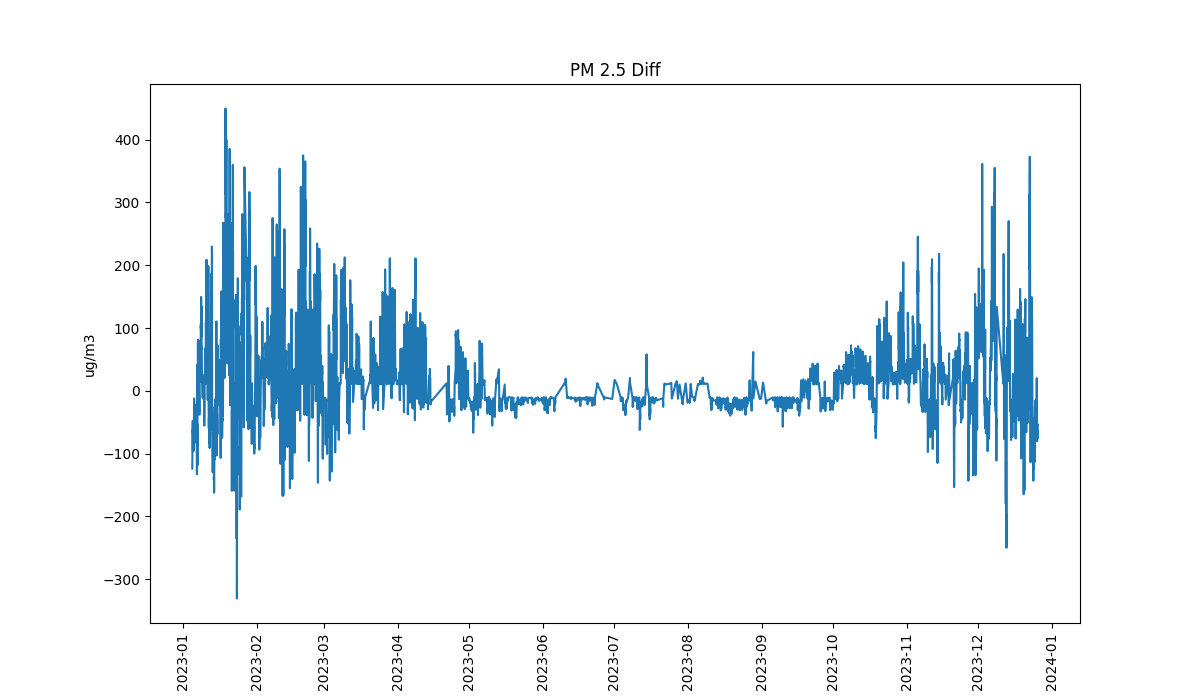

In [5]:
%matplotlib widget
import pandas as pd
import glob
from matplotlib.dates import MonthLocator, DateFormatter
import matplotlib.pyplot as plt

####################
# load airnow data #
####################

# get a list of file paths that match the pattern
airnow_files = glob.glob('airnow/BanjaLuka_PM2.5_*.csv')

# list to store dfs
airnow_df_parts = []

# iterate over the file paths and read each file
for airnow_file in airnow_files:

    # load the CSV file, include only the columns we need, and parse the dates
    df = pd.read_csv(airnow_file, usecols = ['Date (LT)', 'Raw Conc.', 'QC Name'])

    df['Date (LT)'] = pd.to_datetime(df['Date (LT)'], utc = False, format = '%Y-%m-%d %I:%M %p')

    # filter rows with "Valid" QC Name and Raw Conc. <= 500
    df = df[(df['QC Name'] == 'Valid') & (df['Raw Conc.'] <= 500)]

    # append the data to the dfs list
    airnow_df_parts.append(df)
#}

airnow_df = pd.concat(airnow_df_parts, ignore_index = True)

airnow_df = airnow_df.sort_values(by = 'Date (LT)')

#######################
# load purpleair data #
#######################

sensor_index = '37541'
pm25_field = 'pm2.5_atm'

# load the CSV file, include only the columns we need, and parse the dates
purpleair_df = pd.read_csv(f'purpleair/{sensor_index}.csv', usecols = ['time_stamp', 'humidity', pm25_field])

purpleair_df['time_stamp'] = pd.to_datetime(purpleair_df['time_stamp'], utc = True)
purpleair_df['time_stamp'] = purpleair_df['time_stamp'].dt.tz_localize(None)

# filter rows with pm2.5 <= 500
purpleair_df = purpleair_df[purpleair_df[pm25_field] <= 500]

################
# create chart #
################

# calculate the difference between the two dataframes
purpleair_df[pm25_field] = airnow_df['Raw Conc.'] - purpleair_df[pm25_field]

# filter both airnow_df and purpleair_df to contain only timestamps present in both dataframes
diff_df = purpleair_df[purpleair_df['time_stamp'].isin(airnow_df['Date (LT)'])]

diff_df = diff_df[abs(diff_df[pm25_field]) > 10]

# set the figure size to fit the width of the screen
plt.figure(figsize=(12, 7))

# plot data
#plt.plot(airnow_df['Date (LT)'], airnow_df['Raw Conc.'])
#plt.plot(purpleair_df['time_stamp'], purpleair_df[pm25_field])
plt.plot(diff_df['time_stamp'], diff_df[pm25_field])

# set labels
plt.ylabel('ug/m3')
plt.title('PM 2.5 Diff')

# set the x-axis tick locator and formatter
plt.gca().xaxis.set_major_locator(MonthLocator())
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))

# rotate the x-axis tick labels
plt.xticks(rotation = 90)

plt.show()
